In [3]:
import numpy as np
from numpy import pi
# importing Qiskit
from qiskit_aer import Aer
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, plot_bloch_multivector

In [4]:
qc = QuantumCircuit(3)

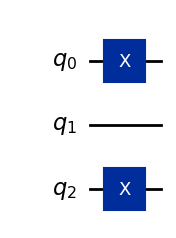

In [5]:
qc.x(0)
qc.x(2)
qc.draw('mpl')

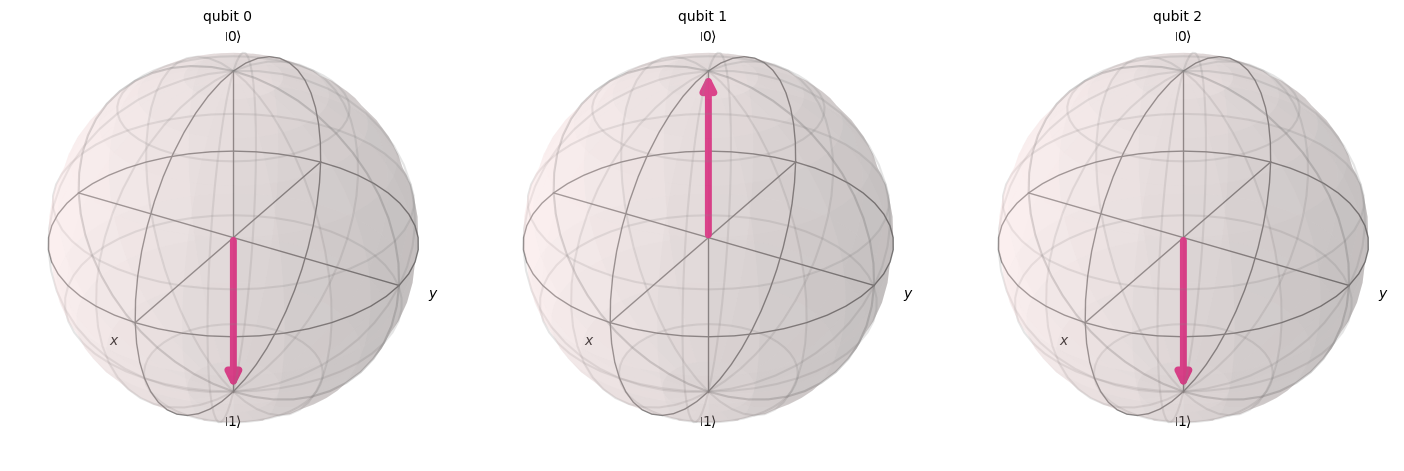

In [6]:
sim = Aer.get_backend("aer_simulator")
qc_init = qc.copy()
qc_init.save_statevector()
statevector = sim.run(qc_init).result().get_statevector()
plot_bloch_multivector(statevector)

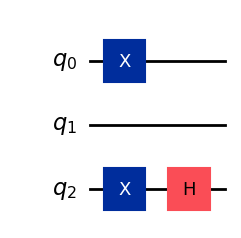

In [7]:
qc.h(2)
qc.draw('mpl')

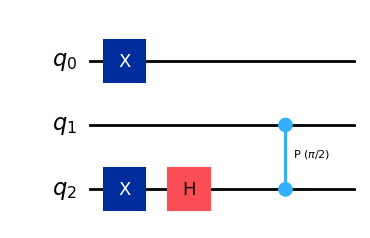

In [8]:
qc.cp(pi/2, 1, 2) # CROT from qubit 1 to qubit 2
qc.draw('mpl')

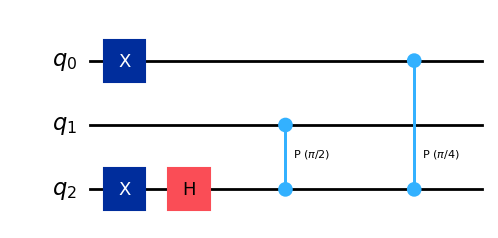

In [9]:
qc.cp(pi/4, 0, 2) # CROT from qubit 2 to qubit 0
qc.draw('mpl')

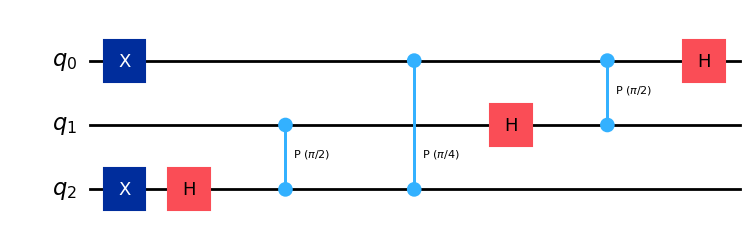

In [10]:
qc.h(1)
qc.cp(pi/2, 0, 1) # CROT from qubit 0 to qubit 1
qc.h(0)
qc.draw('mpl')

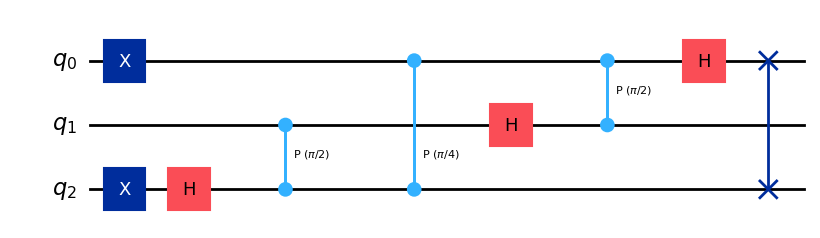

In [11]:
qc.swap(0,2)
qc.draw('mpl')

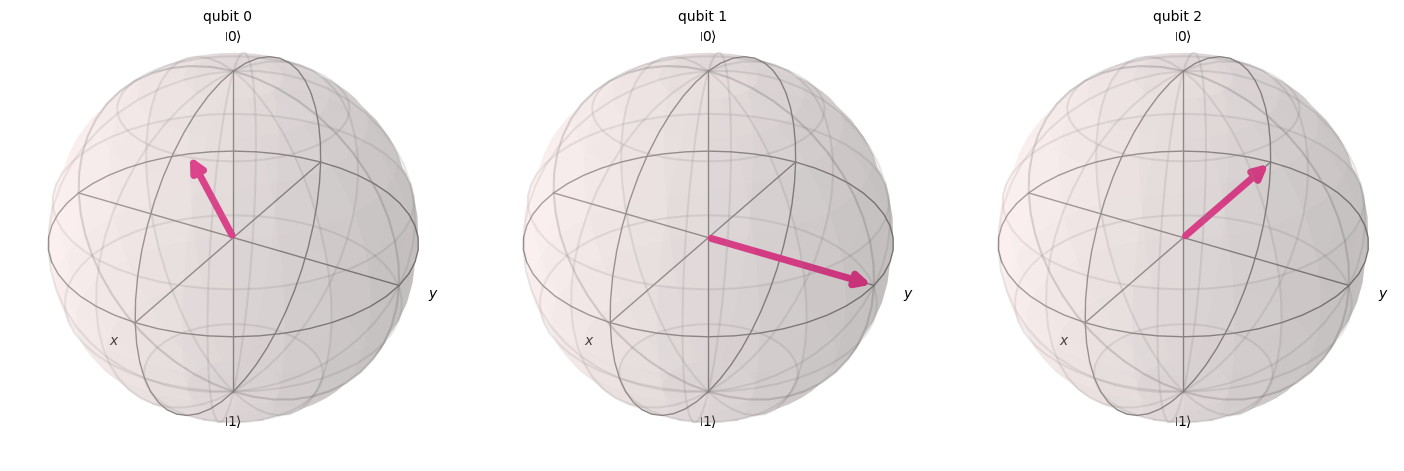

In [12]:
sim = Aer.get_backend("aer_simulator")
qc_init = qc.copy()
qc_init.save_statevector()
statevector = sim.run(qc_init).result().get_statevector()
plot_bloch_multivector(statevector)

In [13]:
import math
from qiskit import QuantumCircuit

def build_qft_like(n: int, do_swaps: bool = True) -> QuantumCircuit:
    """
    Builds a QFT-like circuit:
      for i=0..n-1:
        H on qubit i
        controlled phase rotations from qubits j>i onto target i
      optional final swaps to reverse order
    """
    qc = QuantumCircuit(n, name=f"QFT_like_{n}")

    for i in range(n):
        qc.h(i)

        # UROT_k blocks: controlled phase rotations
        # control = j, target = i
        for j in range(i + 1, n):
            k = j - i + 1                    # gives 2,3,4,... like UROT_2, UROT_3, ...
            theta = math.pi / (2 ** (k - 1)) # pi/2, pi/4, pi/8, ...
            qc.cp(theta, j, i)               # controlled phase (like CU1)

    if do_swaps:
        for i in range(n // 2):
            qc.swap(i, n - 1 - i)

    return qc

def calculate_vector_qft_and_inverse(n: int):
    """
    Builds the QFT-like circuit and its inverse, and calculates their statevectors.
    """
    qc = build_qft_like(n)
    qc_inverse = qc.inverse()

    sim = Aer.get_backend("aer_simulator")

    # Calculate statevector for QFT-like circuit
    qc_init = qc.copy()
    qc_init.save_statevector()
    statevector_qft = sim.run(qc_init).result().get_statevector()

    # Calculate statevector for inverse QFT-like circuit
    qc_inverse_init = qc_inverse.copy()
    qc_inverse_init.save_statevector()
    statevector_qft_inverse = sim.run(qc_inverse_init).result().get_statevector()

    return statevector_qft, statevector_qft_inverse


# Example: "my own input"
n = int(input("How many qubits? "))
qc = build_qft_like(n)
qc_inverse = qc.inverse()
print(qc.draw("text"))
print(qc_inverse.draw("text"))

print("Calculating statevectors...")
statevector_qft, statevector_qft_inverse = calculate_vector_qft_and_inverse(n)
print("\n Statevector for QFT-like circuit:")
print(statevector_qft)

print("\n Statevector for inverse QFT-like circuit:")
print(statevector_qft_inverse)

     ┌───┐                                                                     »
q_0: ┤ H ├─■────────■─────────────■────────────────────────────────────────────»
     └───┘ │P(π/2)  │       ┌───┐ │                                            »
q_1: ──────■────────┼───────┤ H ├─┼────────■────────■───────────────────────X──»
                    │P(π/4) └───┘ │        │P(π/2)  │       ┌───┐           │  »
q_2: ───────────────■─────────────┼────────■────────┼───────┤ H ├─■─────────X──»
                                  │P(π/8)           │P(π/4) └───┘ │P(π/2) ┌───┐»
q_3: ─────────────────────────────■─────────────────■─────────────■───────┤ H ├»
                                                                          └───┘»
«        
«q_0: ─X─
«      │ 
«q_1: ─┼─
«      │ 
«q_2: ─┼─
«      │ 
«q_3: ─X─
«        
                                                                            »
q_0: ────X──────────────────────────────────────────■──────────────■────────»
         │               